In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.preprocessing.pca import PCA
from src.preprocessing.lda import LDA
from src.models.knn import KNN
from src.models.neural_network import NeuralNetwork
from src.evaluation.metrics import accuracy, precision, recall, f1_score, confusion_matrix

In [5]:
data_path = Path("../data/processed/dry_bean_processed.npz")

data = np.load(data_path, allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

classes = data["classes"]
features = data["features"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("Classes:", classes)

X_train: (10836, 16)
X_test : (2707, 16)
y_train: (10836,)
y_test : (2707,)
Classes: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [6]:
n_components_values = [2, 3, 4, 5, 6]

In [7]:
lda_results = {}
lda_predictions = {}
lda_confusion_matrices = {}

In [8]:
for k in n_components_values:

    lda = LDA(n_components=k)

    lda.fit(X_train, y_train)

    X_train_lda = lda.transform(X_train)
    X_test_lda = lda.transform(X_test)

    knn = KNN(
        k=5,
        weights="uniform"
    )

    knn.fit(X_train_lda, y_train)

    y_pred = knn.predict(X_test_lda)

    model_name = f"KNN + LDA({k})"

    lda_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    lda_predictions[model_name] = y_pred

    lda_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

In [9]:
for k in n_components_values:

    lda = LDA(n_components=k)

    lda.fit(X_train, y_train)

    X_train_lda = lda.transform(X_train)
    X_test_lda = lda.transform(X_test)

    nn = NeuralNetwork(
        layer_sizes=[k, 32, 16, 7],
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        dropout_rate=0.0,
        random_state=42
    )

    nn.fit(X_train_lda, y_train)

    y_pred = nn.predict(X_test_lda)

    model_name = f"Neural Network + LDA({k})"

    lda_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    lda_predictions[model_name] = y_pred

    lda_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

In [10]:
lda_results_df = pd.DataFrame(lda_results).T
lda_results_df

,Accuracy,Precision,Recall,F1
KNN + LDA(2),0.816033,0.834168,0.833872,0.833694
KNN + LDA(3),0.900997,0.914731,0.910717,0.912518
KNN + LDA(4),0.911341,0.924085,0.920318,0.921980
KNN + LDA(5),0.916882,0.930771,0.927713,0.929201
KNN + LDA(6),0.921315,0.934062,0.930931,0.932454
Neural Network + LDA(2),0.736239,0.804005,0.746585,0.743652
Neural Network + LDA(3),0.853713,0.887430,0.855359,0.867484
Neural Network + LDA(4),0.876616,0.892144,0.876072,0.882856
Neural Network + LDA(5),0.878094,0.909712,0.887210,0.896031
Neural Network + LDA(6),0.892132,0.920079,0.898133,0.907313


In [11]:
lda_results_df.to_csv(
    "../experiments/comparison/lda_results.csv"
)

In [12]:
PCA_COMPONENTS = 8

In [13]:
pca = PCA(n_components=PCA_COMPONENTS)

pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [14]:
pca_lda_results = {}
pca_lda_predictions = {}
pca_lda_confusion_matrices = {}

In [15]:
for k in n_components_values:

    lda = LDA(n_components=k)

    lda.fit(X_train_pca, y_train)

    X_train_pca_lda = lda.transform(X_train_pca)
    X_test_pca_lda = lda.transform(X_test_pca)

    knn = KNN(
        k=5,
        weights="uniform"
    )

    knn.fit(X_train_pca_lda, y_train)

    y_pred = knn.predict(X_test_pca_lda)
    model_name = f"KNN + PCA(8) + LDA({k})"

    pca_lda_predictions[model_name] = y_pred
    pca_lda_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

    pca_lda_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

In [16]:
pca_lda_knn_results_df = pd.DataFrame(pca_lda_results).T
pca_lda_knn_results_df

pca_lda_knn_results_df.to_csv(
    "../experiments/comparison/pca_lda_knn_results.csv"
)

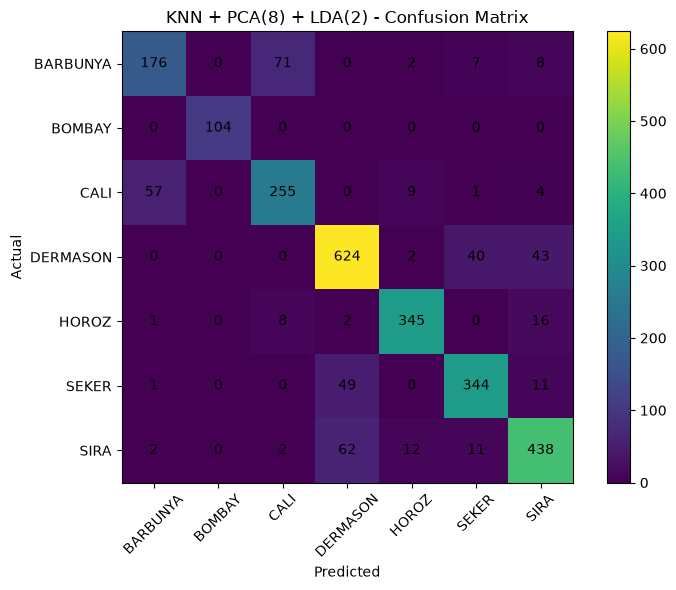

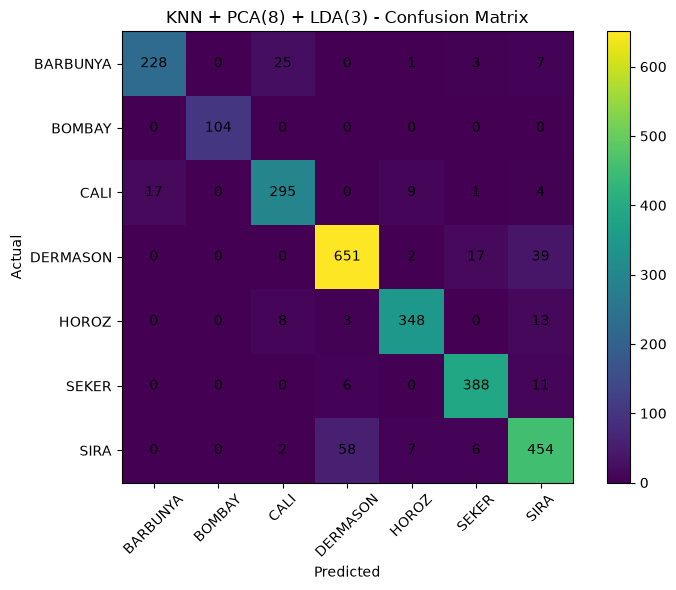

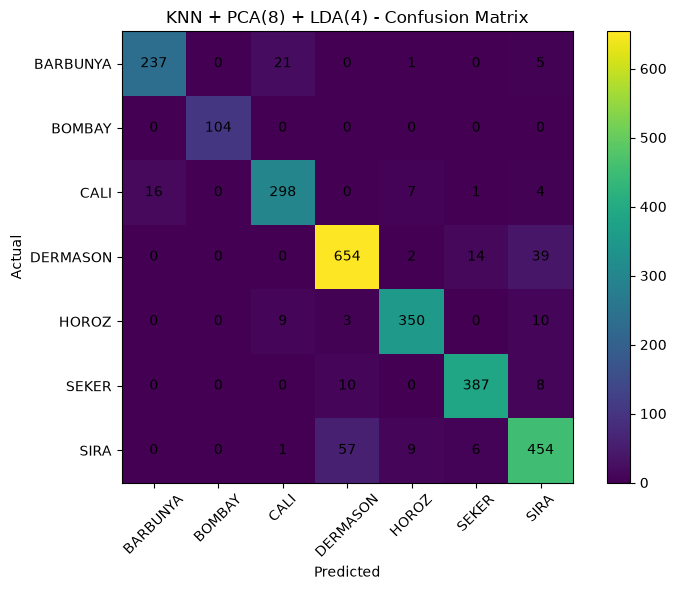

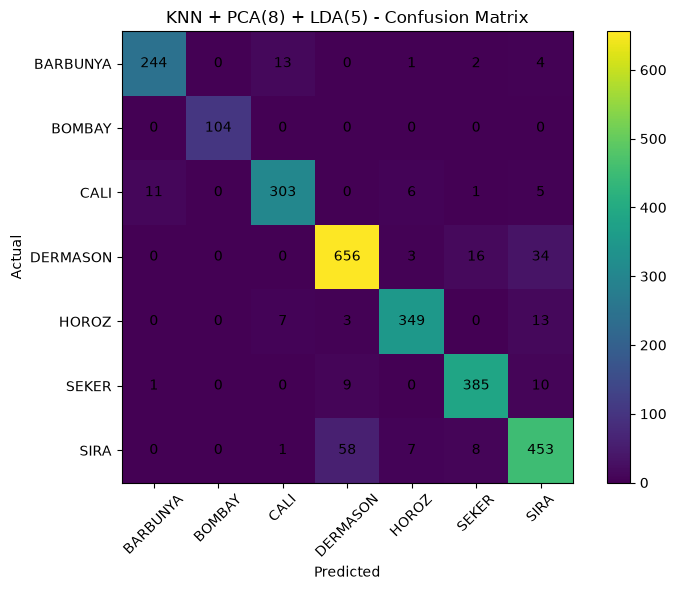

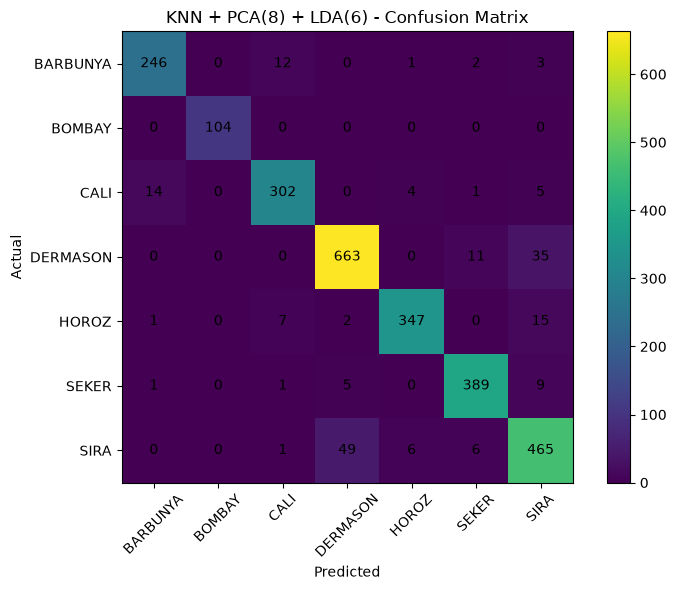

In [17]:
for model_name, cm in pca_lda_confusion_matrices.items():

    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45
    )

    plt.yticks(
        range(len(classes)),
        classes
    )

    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

In [18]:
pca_lda_nn_results = {}
pca_lda_nn_confusion_matrices = {}

for k in n_components_values:

    lda = LDA(n_components=k)

    lda.fit(X_train_pca, y_train)

    X_train_pca_lda = lda.transform(X_train_pca)
    X_test_pca_lda = lda.transform(X_test_pca)

    nn = NeuralNetwork(
        layer_sizes=[k, 32, 16, 7],
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        dropout_rate=0.0,
        random_state=42
    )

    nn.fit(X_train_pca_lda, y_train)

    y_pred = nn.predict(X_test_pca_lda)

    model_name = f"Neural Network + PCA(8) + LDA({k})"

    pca_lda_nn_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    pca_lda_nn_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

pca_lda_nn_results_df = pd.DataFrame(
    pca_lda_nn_results
).T

pca_lda_nn_results_df

,Accuracy,Precision,Recall,F1
Neural Network + PCA(8) + LDA(2),0.854082,0.869329,0.858151,0.862622
Neural Network + PCA(8) + LDA(3),0.920946,0.932470,0.929628,0.930839
Neural Network + PCA(8) + LDA(4),0.921315,0.932675,0.931230,0.931852
Neural Network + PCA(8) + LDA(5),0.925748,0.937187,0.936038,0.936581
Neural Network + PCA(8) + LDA(6),0.931289,0.943255,0.941389,0.942286


In [19]:
pca_lda_nn_results_df.to_csv(
    "../experiments/comparison/pca_lda_nn_results.csv"
)

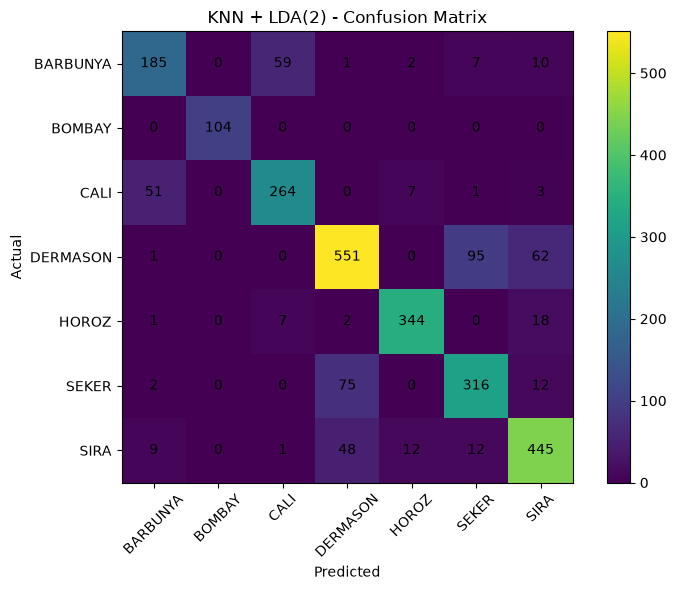

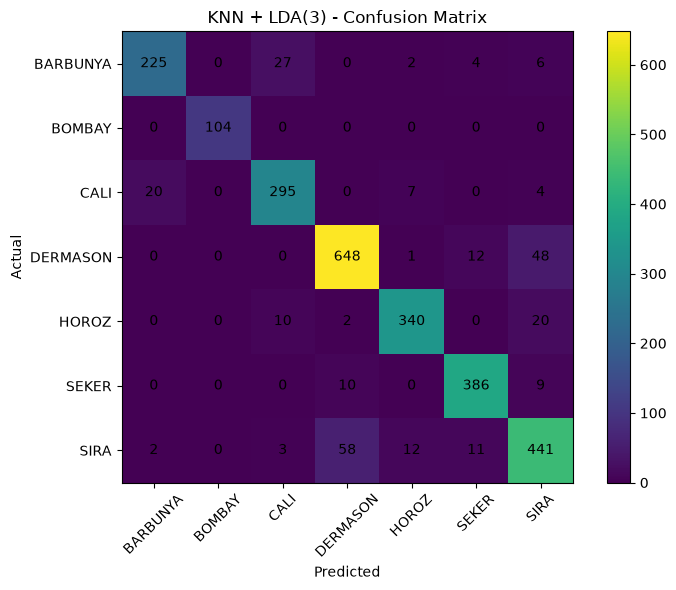

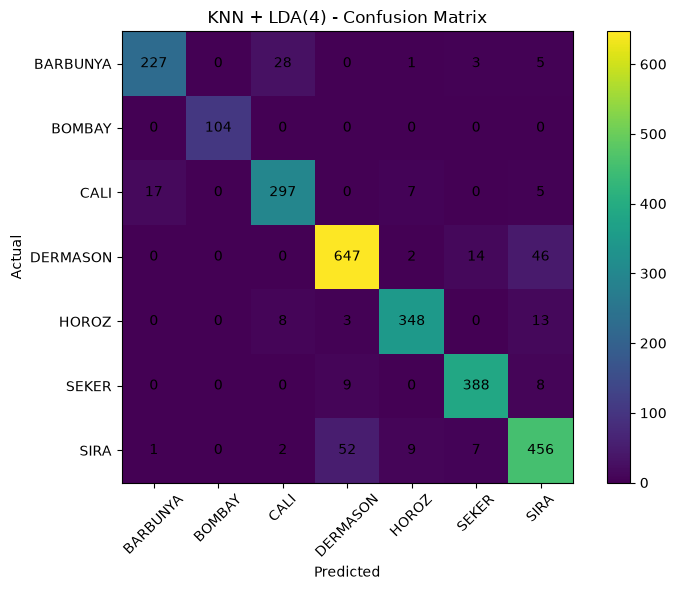

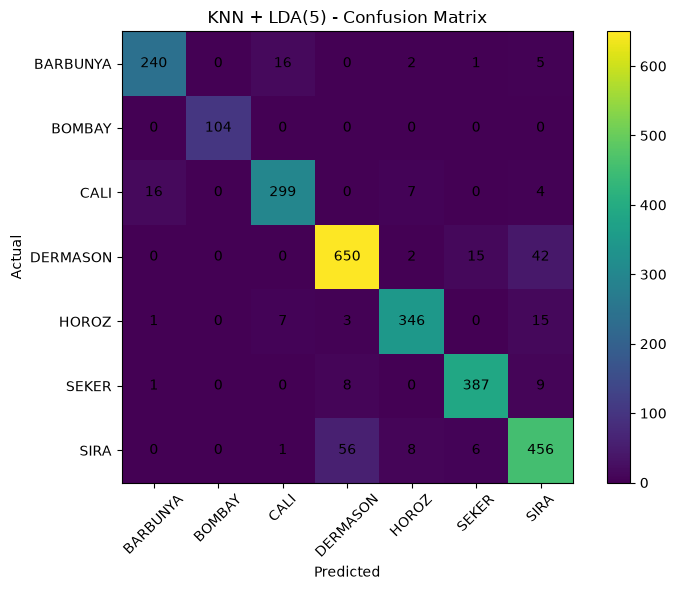

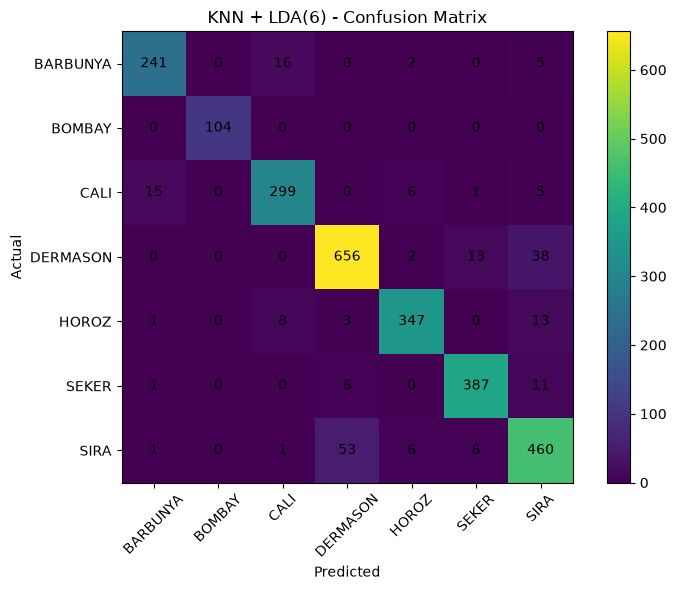

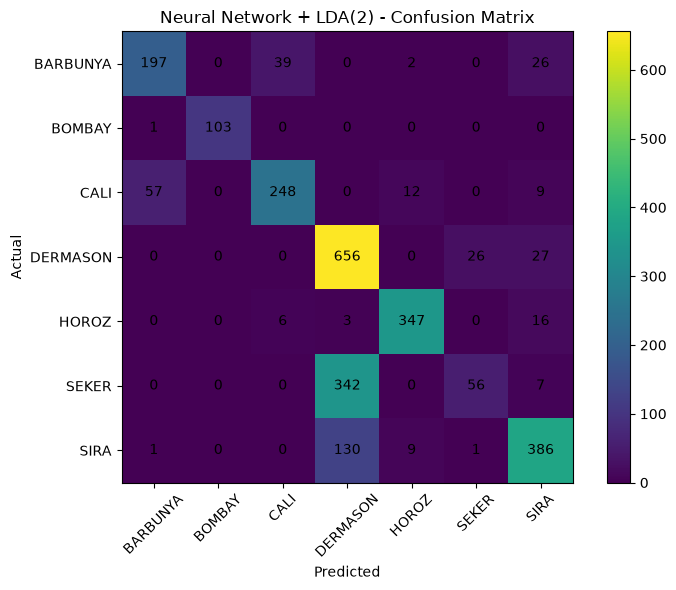

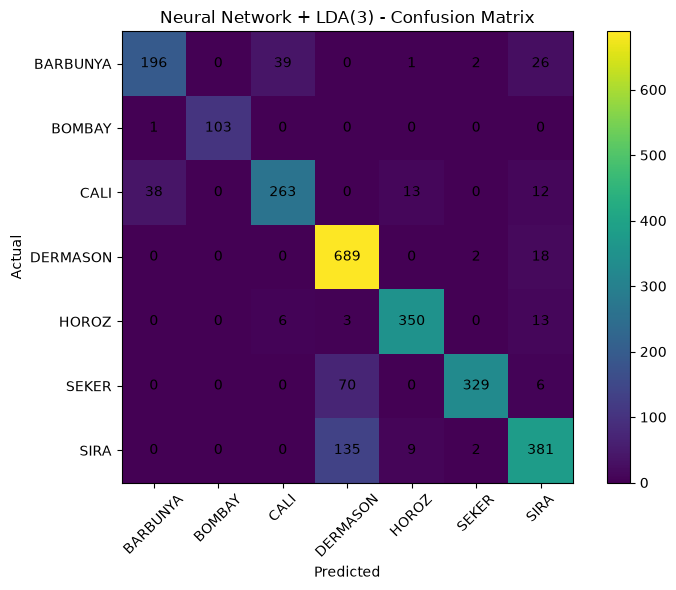

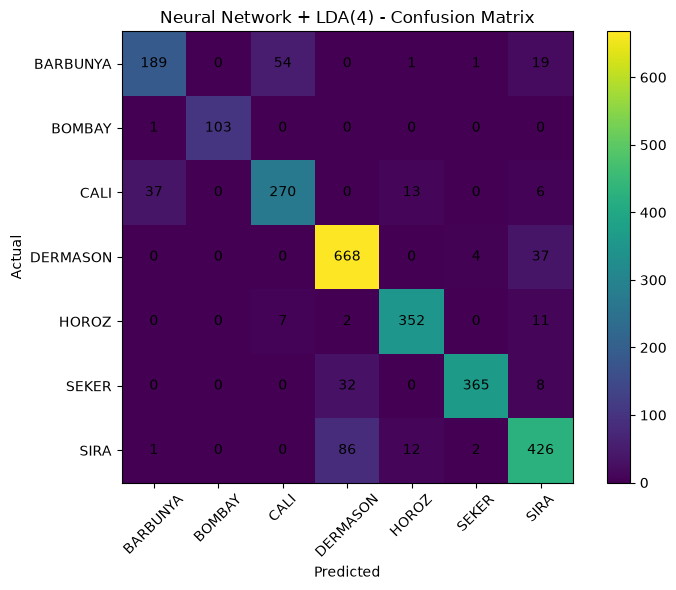

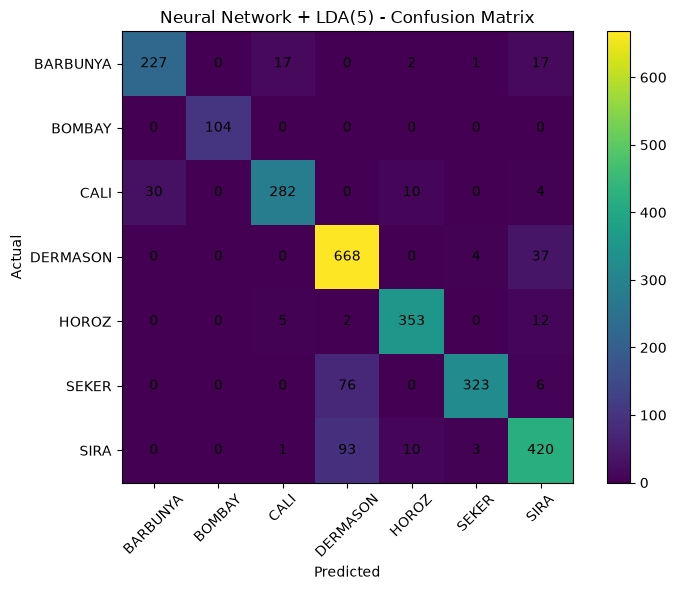

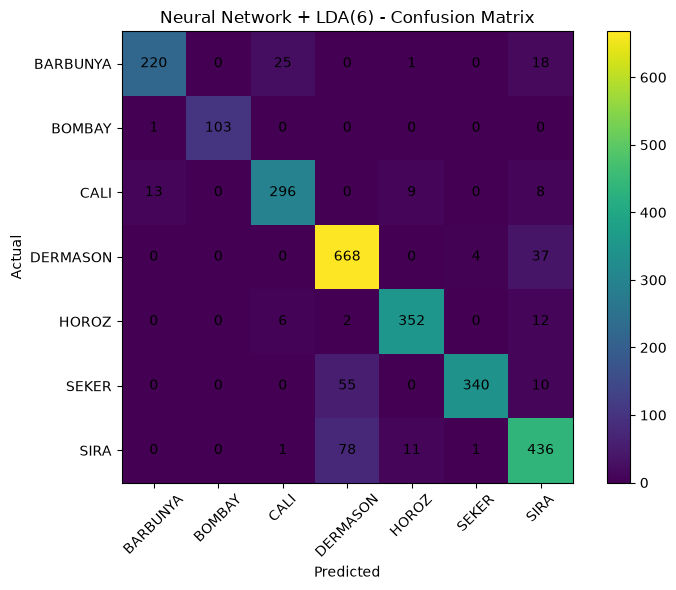

In [20]:
for model_name, cm in lda_confusion_matrices.items():

    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45
    )

    plt.yticks(
        range(len(classes)),
        classes
    )

    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

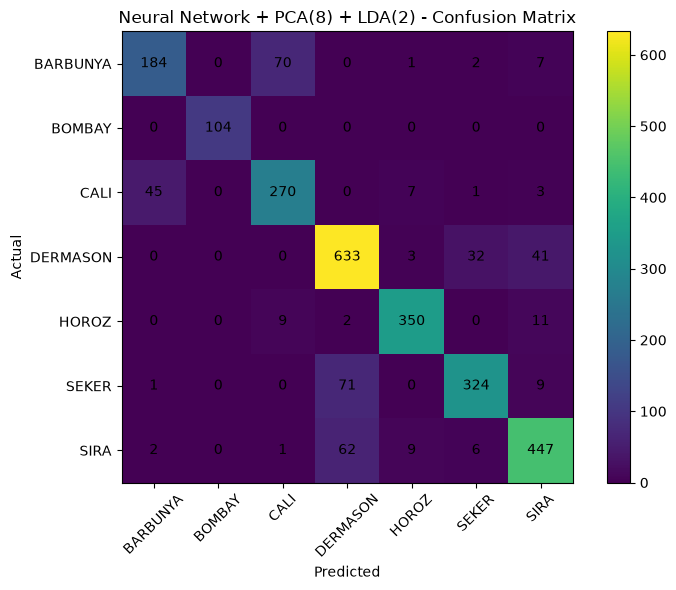

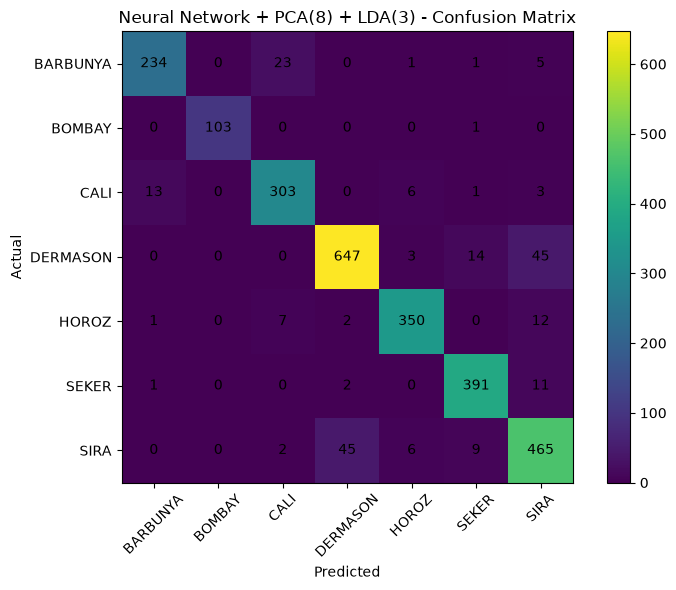

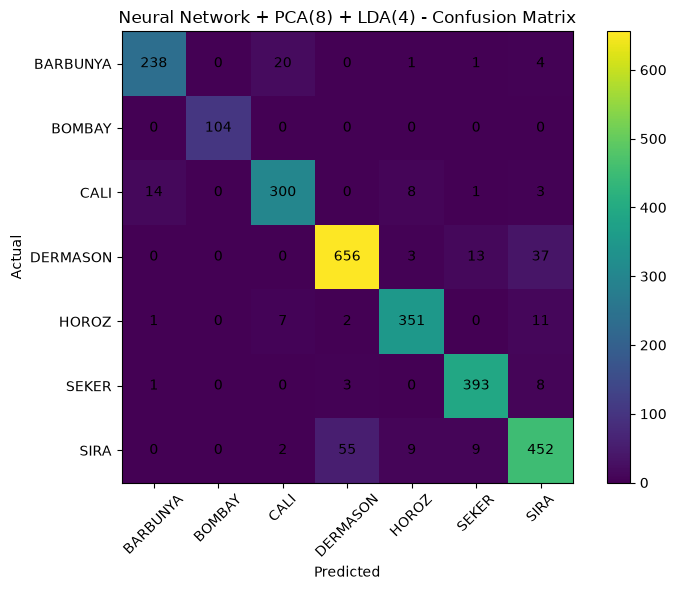

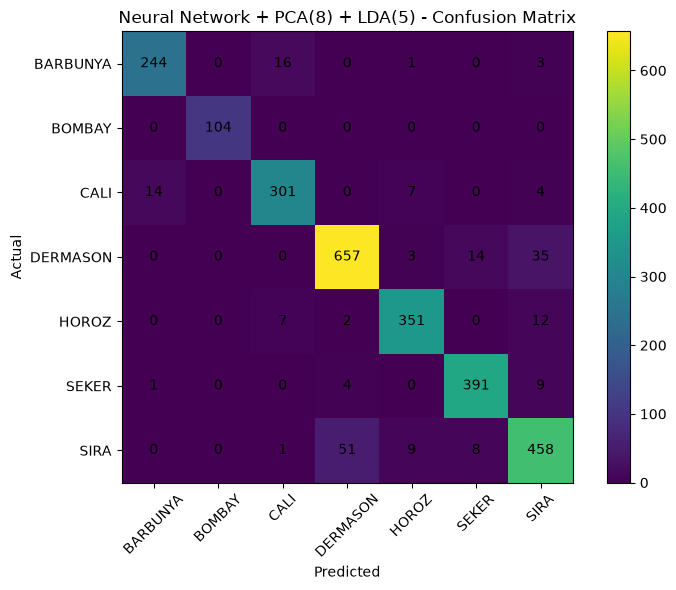

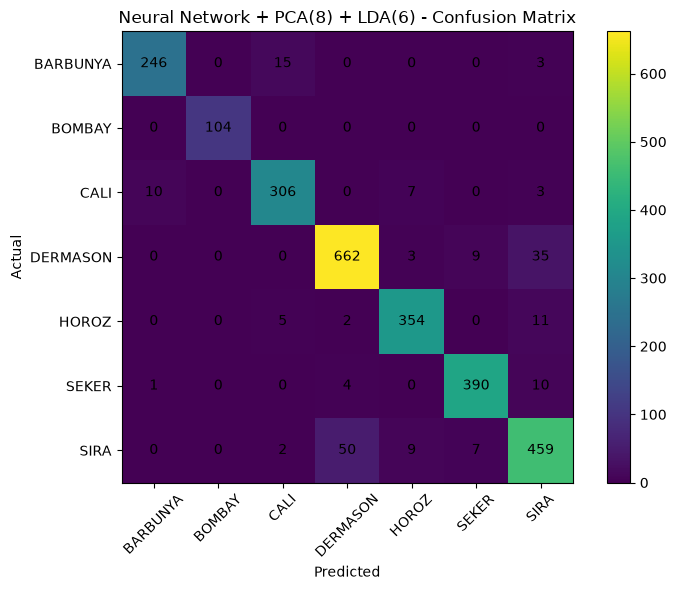

In [21]:
for model_name, cm in pca_lda_nn_confusion_matrices.items():

    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45
    )

    plt.yticks(
        range(len(classes)),
        classes
    )

    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()